## STEP 04: Business Analysis with Python

## Load the data

In [1]:
import pandas as pd

customers = pd.read_csv("../data/customers.csv")
plans = pd.read_csv("../data/plans.csv")
usage = pd.read_csv("../data/usage.csv")
revenue = pd.read_csv("../data/revenue.csv")

## KPI 1: Total Revenue

In [2]:
total_revenue = revenue["revenue"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $3,607,446.75


## KPI 2: Number of clients

In [3]:
customers["customer_id"].nunique()

10000

## KPI 3: ARPU

In [4]:
arpu = revenue["revenue"].sum() / customers["customer_id"].nunique()

print(round(arpu,2))

360.74


In [9]:
monthly_arpu = (
    revenue["revenue"].sum()
    /
    customers["customer_id"].nunique()
    /
    24
)

print(monthly_arpu)

15.031028124999999


## KPI 4: Revenue per Offer

In [5]:
cust_plan = customers[["customer_id","plan_id"]]

rev_plan = revenue.merge(
    cust_plan,
    on="customer_id"
)

revenue_by_plan = rev_plan.groupby(
    "plan_id"
)["revenue"].sum().reset_index()

revenue_by_plan

,plan_id,revenue
0,1,662815.33
1,2,881587.50
2,3,1049080.44
3,4,1013963.48


## KPI 5: Top 10 Cities

In [6]:
rev_city = revenue.merge(
    customers[["customer_id","city"]],
    on="customer_id"
)

top_cities = rev_city.groupby(
    "city"
)["revenue"].sum().sort_values(
    ascending=False
)

top_cities.head(10)

city
Lubumbashi    388128.24
Kinshasa      376113.18
Kisangani     366045.62
Matadi        362746.55
Kolwezi       362598.80
Kananga       356983.26
Likasi        354616.78
Goma          354493.09
Bukavu        350054.66
Mbuji-Mayi    335666.57
Name: revenue, dtype: float64

## KPI 6: Monthly Revenue

In [7]:
monthly_revenue = revenue.groupby(
    "month"
)["revenue"].sum().reset_index()

monthly_revenue.head()

,month,revenue
0,2024-01-01,150443.60
1,2024-02-01,150345.25
2,2024-03-01,150298.96
3,2024-04-01,150110.50
4,2024-05-01,150304.09


## First chart

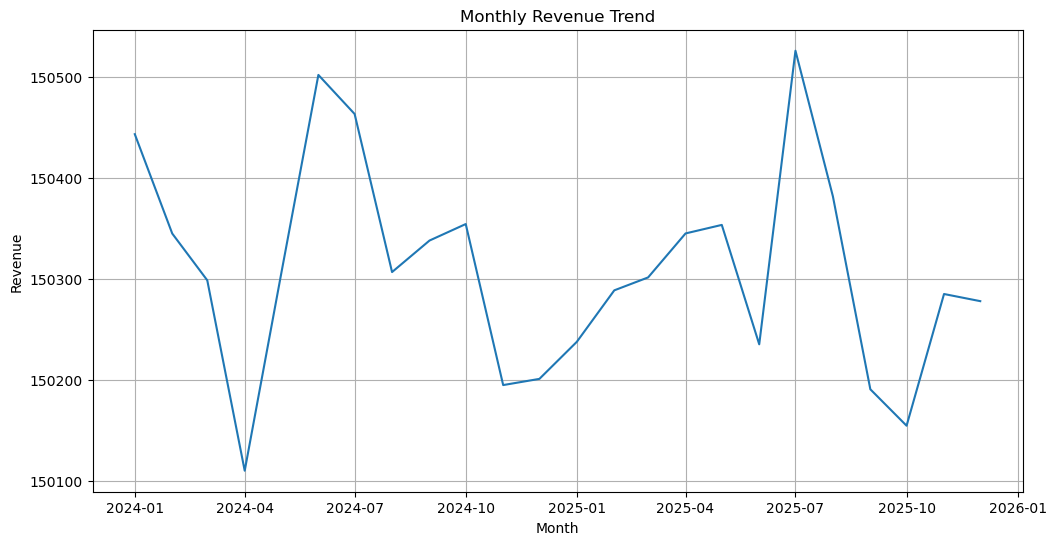

In [8]:
import matplotlib.pyplot as plt

monthly_revenue["month"] = pd.to_datetime(
    monthly_revenue["month"]
)

plt.figure(figsize=(12,6))
plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"]
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

## KPI: Revenue per Plan

In [10]:
plan_analysis = revenue.merge(
    customers[['customer_id','plan_id']],
    on='customer_id'
).merge(
    plans,
    on='plan_id'
)

plan_analysis.groupby(
    'plan_name'
)['revenue'].agg(
    ['sum','mean','count']
).sort_values(
    by='sum',
    ascending=False
)

,sum,mean,count
plan_name,,,
Gold,1049080.44,21.998835,47688
Unlimited,1013963.48,41.996499,24144
Silver,881587.50,11.996346,73488
Basic,662815.33,7.000584,94680


## KPI : Top 10 clients

In [11]:
top_customers = revenue.groupby(
    'customer_id'
)['revenue'].sum().sort_values(
    ascending=False
)

top_customers.head(10)

customer_id
C06165    1022.69
C07860    1022.24
C00226    1020.65
C01743    1020.54
C07299    1020.26
C02412    1020.23
C04215    1020.14
C03814    1019.72
C06694    1019.68
C08229    1019.64
Name: revenue, dtype: float64

## KPI: Internet Usage by Plan

In [12]:
usage_plan = usage.merge(
    customers[['customer_id','plan_id']],
    on='customer_id'
).merge(
    plans,
    on='plan_id'
)

usage_plan.groupby(
    'plan_name'
)['data_gb'].mean().sort_values(
    ascending=False
)

plan_name
Unlimited    79.926547
Gold         34.948281
Silver       14.995397
Basic         4.998966
Name: data_gb, dtype: float64